In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import os
from src.utils import load_json
import seaborn as sns
from case_study.utils import process_metadata, set_matplot_style, BI_PART_COLORS
from src.utils import load_env
set_matplot_style()

env_vars = load_env()
podcast_path = f"{env_vars["RAW_DATA_DIR"]}/podcasts"

/Users/aleto/projects/metaphor-detector/env/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
all_metadata = process_metadata(f"{podcast_path}/metadata")

In [4]:
df = pd.DataFrame(all_metadata).T
right_df = df[df["spin"] == "right"]

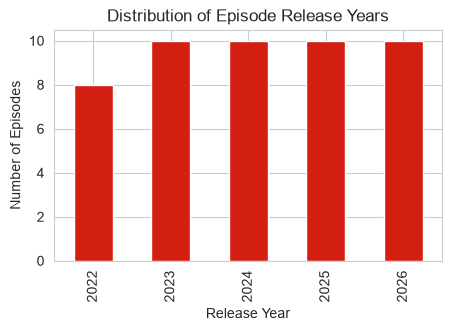

In [5]:
def clean_date(date_str):
    date_str = date_str.split("T")[0]  # get the date part
    try:
        return pd.to_datetime(date_str)
    except Exception as e:
        print(f"Error parsing date '{date_str}': {e}")
        return pd.NaT

# plot the date distribution of episodes
right_df["episode_date_clean"] = right_df["episode_date"].apply(clean_date)
right_df["release_year"] = right_df["episode_date_clean"].dt.year
plt.figure(figsize=(5, 3)) # adjust figure size and resolution
right_df["release_year"].value_counts().sort_index().plot(kind="bar", color=BI_PART_COLORS["right"])
plt.title("Distribution of Episode Release Years")
plt.xlabel("Release Year")
plt.ylabel("Number of Episodes")
plt.show()

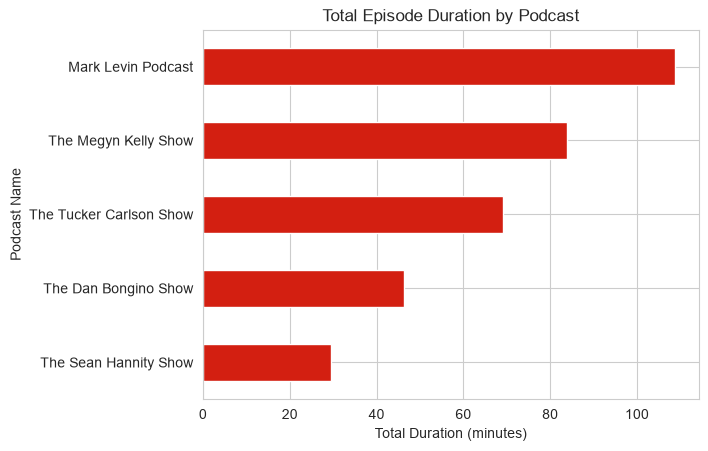

In [6]:
# plot duration per podcast name 
right_df["duration_minutes"] = right_df["duration"] / 60
right_df.groupby("podcast_name")["duration_minutes"].mean().sort_values().plot(kind="barh", color=BI_PART_COLORS["right"])
plt.title("Total Episode Duration by Podcast")
plt.xlabel("Total Duration (minutes)")
plt.ylabel("Podcast Name")
plt.show()

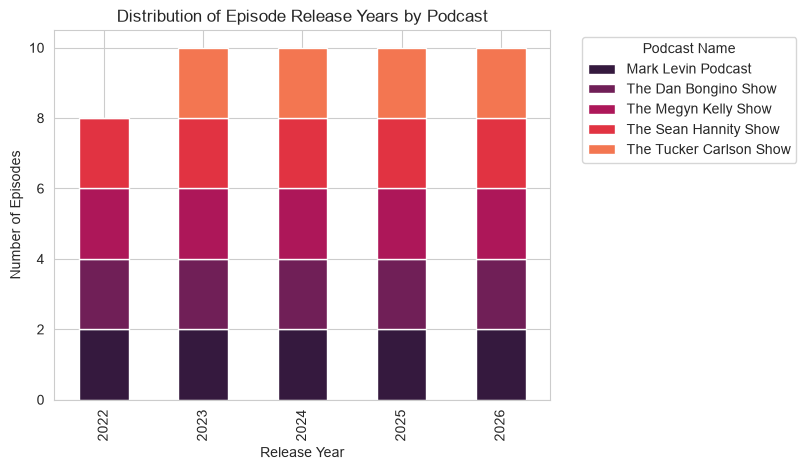

In [7]:
# plot episode years per podcast
sns.set_palette("rocket")
right_df.groupby("podcast_name")["release_year"].value_counts().unstack().fillna(0).T.plot(kind="bar", stacked=True)
plt.title("Distribution of Episode Release Years by Podcast")
plt.xlabel("Release Year")
plt.ylabel("Number of Episodes")
plt.legend(title="Podcast Name", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

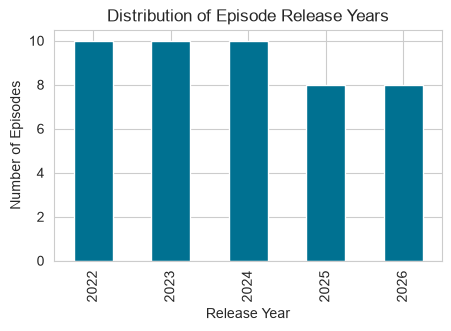

In [8]:
left_df = df[df["spin"] == "left"]
left_df["episode_date_clean"] = left_df["episode_date"].apply(clean_date)
left_df["release_year"] = left_df["episode_date_clean"].dt.year
plt.figure(figsize=(5, 3)) # adjust figure size and resolution
left_df["release_year"].value_counts().sort_index().plot(kind="bar", color=BI_PART_COLORS["left"])
plt.title("Distribution of Episode Release Years")
plt.xlabel("Release Year")
plt.ylabel("Number of Episodes")
plt.show()

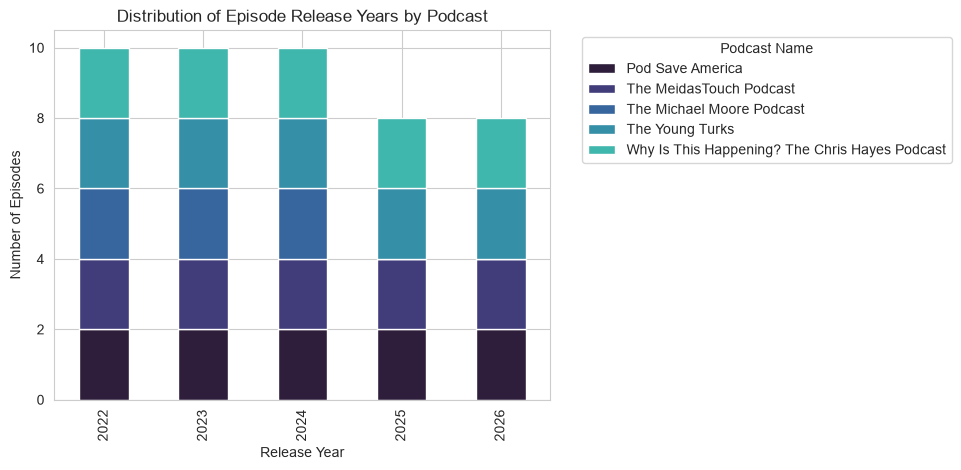

In [9]:
sns.set_palette("mako")
left_df.groupby("podcast_name")["release_year"].value_counts().unstack().fillna(0).T.plot(kind="bar", stacked=True)
plt.title("Distribution of Episode Release Years by Podcast")
plt.xlabel("Release Year")
plt.ylabel("Number of Episodes")
plt.legend(title="Podcast Name", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

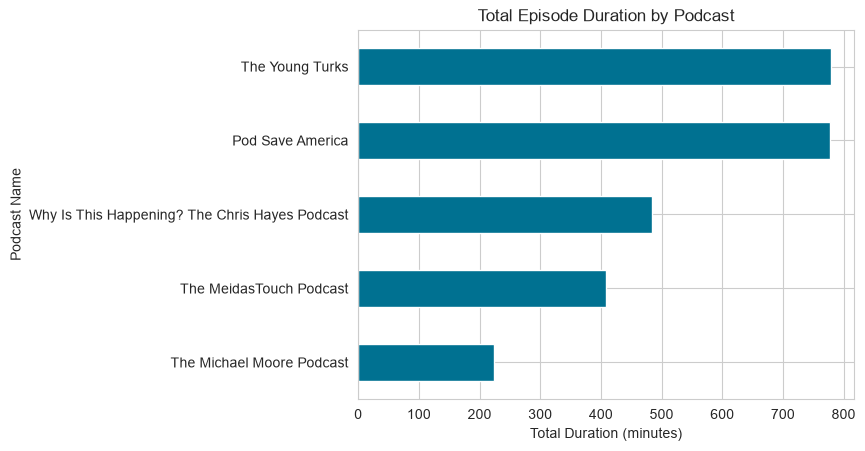

In [10]:
# plot duration per podcast name 
left_df["duration_minutes"] = left_df["duration"] / 60
left_df.groupby("podcast_name")["duration_minutes"].sum().sort_values().plot(kind="barh", color=BI_PART_COLORS["left"])
plt.title("Total Episode Duration by Podcast")
plt.xlabel("Total Duration (minutes)")
plt.ylabel("Podcast Name")
plt.show()